In [1]:
# Imports and Setup

# Data manipulation and n-dimensional arrays
import numpy as np
import pandas as pd
import xarray as xr

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Classical Machine Learning and Preprocessing (Scikit-Learn)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error

# Statistics and Plotting
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Set device. If your machine has access to a GPU and cuda is installed/configured, use the GPU. 
# If not, use the cpu. To install CUDA: https://docs.nvidia.com/cuda/cuda-installation-guide-linux/index.html 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


/home/ben-martinez/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Download the example datasets from zenodo 

# WARNING! These files are about 3 GB in total.

import os
import urllib.request

zenodo_record_id = "20769370"

# Dictionary mapping the required local filenames to their exact names on Zenodo
files_to_download = {
    "TEC_CEDAR.nc": "TEC_CEDAR.nc",
    "JAWARA_CEDAR.nc": "JAWARA_CEDAR.nc"
}

print("Checking local directory for required scientific datasets...")

for local_name, zenodo_name in files_to_download.items():
    if not os.path.exists(local_name):
        print(f"Downloading {local_name} from Zenodo. This may take a moment depending on your connection...")
        
        url = f"https://zenodo.org/records/{zenodo_record_id}/files/{zenodo_name}?download=1"
        
        try:
            urllib.request.urlretrieve(url, local_name)
            print(f"Successfully downloaded {local_name}.")
        except Exception as e:
            print(f"Failed to download {local_name}. Error: {e}")
    else:
        print(f"File {local_name} already exists locally. Skipping download.")

print("Data validation complete. The notebook is ready to proceed.")

Checking local directory for required scientific datasets...
File TEC_CEDAR.nc already exists locally. Skipping download.
File JAWARA_CEDAR.nc already exists locally. Skipping download.
Data validation complete. The notebook is ready to proceed.


In [3]:
# Data Loading and Alignment

# Load and align datasets
ds_TEC = xr.open_dataset('TEC_CEDAR.nc') # TEC dataset. This is what we want our model to predict. 
# Dst, F10.7 are also included and will be used as temporal drivers.
print(ds_TEC) 

ds_JAWARA = xr.open_dataset('JAWARA_CEDAR.nc') # Neutral atmosphere T, U, V @ ~97km from reanalysis to drive model. 
ds_JAWARA = ds_JAWARA.assign_coords(longitude=(((ds_JAWARA.longitude + 180) % 360) - 180))
print(ds_JAWARA) 

# Feature engineering: inject temporal lag to lower atmosphere driver (JAWARA)
LAG_HOURS = 24
print(f"Applying a {LAG_HOURS}-hour lag to the lower atmospheric drivers...")

# Shift JAWARA time labels forward to align past forcing with current TEC
ds_JAWARA = ds_JAWARA.assign_coords(time=ds_JAWARA.time + np.timedelta64(LAG_HOURS, 'h'))

# Intersect time to ensure alignment across both files
common_times = np.intersect1d(ds_TEC.time.values, ds_JAWARA.time.values)
ds_TEC = ds_TEC.sel(time=common_times)
ds_JAWARA = ds_JAWARA.sel(time=common_times)

# Interpolate JAWARA to TEC spatial grid
print("Interpolating JAWARA spatial grid to TEC coordinates...")
ds_JAWARA_interp = ds_JAWARA.interp(latitude=ds_TEC.lat, longitude=ds_TEC.lon)

<xarray.Dataset> Size: 409MB
Dimensions:   (time: 9600, lat: 73, lon: 73)
Coordinates:
  * time      (time) datetime64[ns] 77kB 2022-12-31 ... 2026-05-02T21:00:00
  * lat       (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
  * lon       (lon) float64 584B -180.0 -175.0 -170.0 ... 170.0 175.0 180.0
Data variables:
    tec_mean  (time, lat, lon) float64 409MB ...
    dst       (time) float64 77kB ...
    f10.7     (time) float64 77kB ...
<xarray.Dataset> Size: 2GB
Dimensions:    (time: 18256, latitude: 71, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 146kB 2020-01-01 ... 2026-03-31T21:00:00
  * latitude   (latitude) float64 568B 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5
  * longitude  (longitude) float64 576B 0.0 5.0 10.0 15.0 ... -15.0 -10.0 -5.0
    level      float32 4B ...
Data variables:
    u          (time, latitude, longitude) float64 747MB ...
    v          (time, latitude, longitude) float64 747MB ...
    t          (time, latitude, lon

In [4]:
# Clean and Normalize Temporal Drivers

print("Normalizing global drivers...")
# Dst and F10.7
temporal_drivers = ds_TEC[['dst', 'f10.7']].to_dataframe().reset_index()
scaler_temporal = StandardScaler() # z-normalize all inputs and outputs (mean --> 0, std --> 1.)
temporal_scaled = scaler_temporal.fit_transform(temporal_drivers[['dst', 'f10.7']])
# This prevents variables with naturally larger ranges from overpowering the neural network.

# Day of Year (Cyclic encoding is better for ML, but we will standardize here to maintain scale)
doy = pd.to_datetime(temporal_drivers['time']).dt.dayofyear.values.reshape(-1, 1)
scaler_doy = StandardScaler()
doy_scaled = scaler_doy.fit_transform(doy)

Normalizing global drivers...


Flattening and reducing JAWARA fields via PCA...
Explained variance by 20 components: 0.73
Generating PCA Explained Variance Curve...


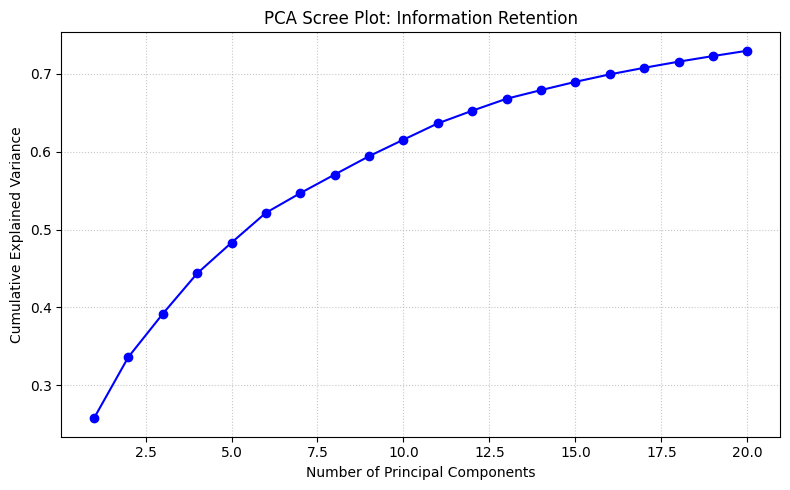

Mapping the spatial structure of the primary EOFs...


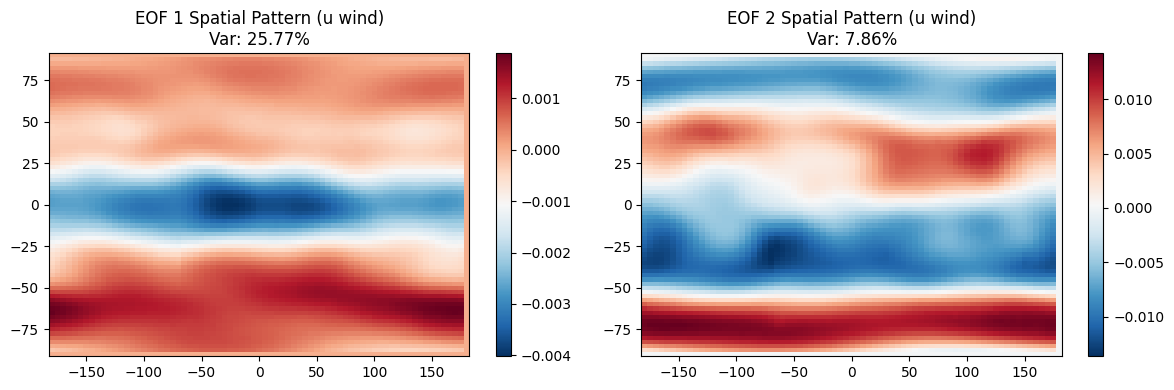

Reconstructing spatial maps from Principal Components...
Generating EOF comparison plot...


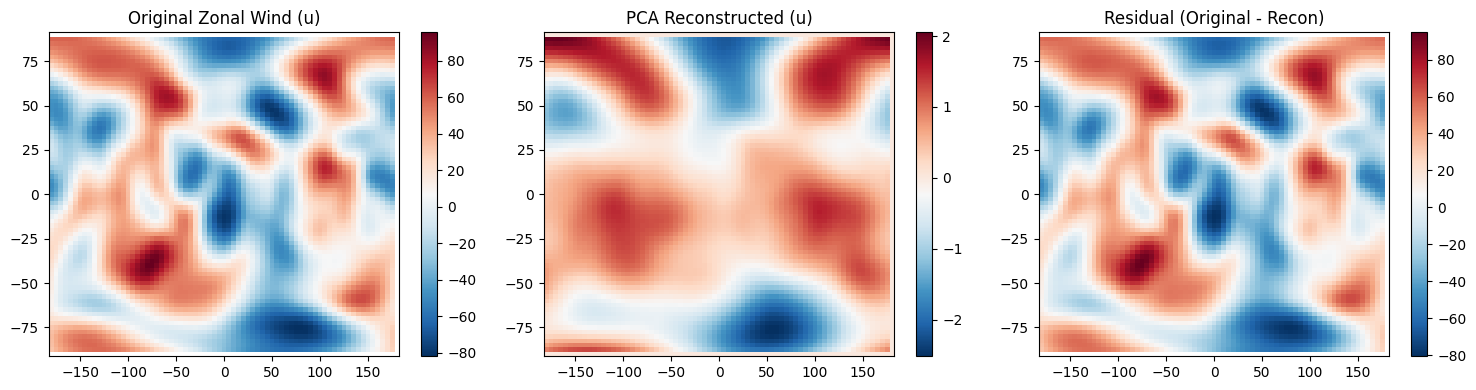

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Flattening and reducing JAWARA fields via PCA...")

# Extract shapes for rebuilding later
num_times = len(common_times)
num_lat = len(ds_TEC.lat)
num_lon = len(ds_TEC.lon)
pixels_per_map = num_lat * num_lon # 73 * 73 = 5329

# Stack u, v, t into (time, spatial_features)
u_flat = ds_JAWARA_interp['u'].values.reshape(num_times, -1)
v_flat = ds_JAWARA_interp['v'].values.reshape(num_times, -1)
t_flat = ds_JAWARA_interp['t'].values.reshape(num_times, -1)

jawara_combined = np.concatenate([u_flat, v_flat, t_flat], axis=1)
jawara_combined = np.nan_to_num(jawara_combined, nan=0.0) 

# Standardize before PCA
scaler_jawara = StandardScaler()
jawara_scaled = scaler_jawara.fit_transform(jawara_combined)

# Compress to Top Principal Components
n_comp = 20
pca = PCA(n_components=n_comp)
jawara_pca = pca.fit_transform(jawara_scaled)

explained_var = np.sum(pca.explained_variance_ratio_)
print(f"Explained variance by {n_comp} components: {explained_var:.2f}")

# Plot the PCA Cumulative Variance Curve 
print("Generating PCA Explained Variance Curve...")
fig_pca, ax_pca = plt.subplots(figsize=(8, 5))
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

ax_pca.plot(range(1, n_comp + 1), cumulative_variance, marker='o', linestyle='-', color='b')
ax_pca.set_xlabel('Number of Principal Components')
ax_pca.set_ylabel('Cumulative Explained Variance')
ax_pca.set_title('PCA Scree Plot: Information Retention')
ax_pca.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('pca_variance_curve.png')
plt.show()

# Plot the Spatial Structure of the first 2 EOFs (for 'u')
print("Mapping the spatial structure of the primary EOFs...")
# pca.components_ has shape (n_components, total_features)
# We slice out the first 'pixels_per_map' segment which corresponds to the 'u' variable
eof_u_spatial = pca.components_[:2, :pixels_per_map].reshape(2, num_lat, num_lon)

fig_eof, axes_eof = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    im = axes_eof[i].pcolormesh(ds_TEC.lon.values, ds_TEC.lat.values, eof_u_spatial[i], cmap='RdBu_r')
    axes_eof[i].set_title(f'EOF {i+1} Spatial Pattern (u wind)\nVar: {pca.explained_variance_ratio_[i]:.2%}')
    fig_eof.colorbar(im, ax=axes_eof[i])

plt.tight_layout()
plt.savefig('eof_spatial_patterns.png')
plt.show()

# Reconstruct the spatial fields from ONLY the top components
print("Reconstructing spatial maps from Principal Components...")
jawara_reconstructed = pca.inverse_transform(jawara_pca)

# Split back into u, v, and t, and reshape to (time, lat, lon)
u_pca_spatial = jawara_reconstructed[:, :pixels_per_map].reshape(num_times, num_lat, num_lon)
v_pca_spatial = jawara_reconstructed[:, pixels_per_map:2*pixels_per_map].reshape(num_times, num_lat, num_lon)
t_pca_spatial = jawara_reconstructed[:, 2*pixels_per_map:].reshape(num_times, num_lat, num_lon)

# Generate a figure for the EOF showing original vs reconstructed
print("Generating EOF comparison plot...")
sample_idx = 0
orig_u = ds_JAWARA_interp['u'].isel(time=sample_idx).values
recon_u = u_pca_spatial[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].pcolormesh(ds_TEC.lon.values, ds_TEC.lat.values, orig_u, cmap='RdBu_r')
axes[0].set_title('Original Zonal Wind (u)')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(ds_TEC.lon.values, ds_TEC.lat.values, recon_u, cmap='RdBu_r')
axes[1].set_title('PCA Reconstructed (u)')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(ds_TEC.lon.values, ds_TEC.lat.values, orig_u - recon_u, cmap='RdBu_r')
axes[2].set_title('Residual (Original - Recon)')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('eof_reconstruction_comparison.png')
plt.show()

In [6]:
# Prepare Spatial Tensors and CNN DataLoaders

print("Constructing spatial tensors...")
lat_grid, lon_grid = np.meshgrid(ds_TEC.lat.values, ds_TEC.lon.values, indexing='ij')

# Normalize coordinates
lat_scaled = lat_grid / 90.0
lon_scaled = lon_grid / 180.0

tec_target = ds_TEC['tec_mean'].values
tec_target = np.nan_to_num(tec_target, nan=0.0)

# Extract UT hours from the aligned time index
print("Constructing spatio-temporal Local Time tensors...")
ut_hours = pd.to_datetime(common_times).hour.values.reshape(-1, 1, 1)

# Calculate continuous Local Time across the grid (Time, Lat, Lon)
lt_grid = (ut_hours + (lon_grid / 15.0)) % 24.0

# Convert to continuous cyclic features to prevent edge artifacts at midnight
lt_sin = np.sin(2 * np.pi * lt_grid / 24.0)
lt_cos = np.cos(2 * np.pi * lt_grid / 24.0)

# Generate Train/Validation split masks locking in Nov 2023 for out-of-sample validation
# Try changing the out-of-sample month! 

print("Generating train/validation split masks...")
time_series = pd.to_datetime(common_times)
val_mask = (time_series.year == 2023) & (time_series.month == 11)
train_mask = ~val_mask

# The PyTorch Dataset object builds specific inputs for our three CNN models.
# PyTorch requires data to be formatted as Tensors rather than standard Numpy arrays or Pandas DataFrames.
class TECDataset(Dataset):
    def __init__(self, doy, temporal, u_map, v_map, t_map, lat_map, lon_map, lt_sin, lt_cos, target):
        # Convert all incoming arrays to 32-bit float tensors, which is the standard precision for neural network weights.
        self.doy = torch.tensor(doy, dtype=torch.float32)
        self.temporal = torch.tensor(temporal, dtype=torch.float32)
        
        self.u_map = torch.tensor(u_map, dtype=torch.float32)
        self.v_map = torch.tensor(v_map, dtype=torch.float32)
        self.t_map = torch.tensor(t_map, dtype=torch.float32)
        
        self.lat_map = torch.tensor(lat_map, dtype=torch.float32)
        self.lon_map = torch.tensor(lon_map, dtype=torch.float32)
        self.lt_sin = torch.tensor(lt_sin, dtype=torch.float32)
        self.lt_cos = torch.tensor(lt_cos, dtype=torch.float32)
        
        # unsqueeze(1) adds an extra dimension so the target shape is [batch_size, 1, lat, lon] instead of [batch_size, lat, lon].
        self.target = torch.tensor(target, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        # Tells the DataLoader exactly how many samples exist in this dataset.
        return len(self.target)

    def __getitem__(self, idx):
        # This method is called automatically during training to fetch one sample at a time.
        H, W = self.lat_map.shape
        
        # M1: Lat, Lon, DOY, Local Time
        # Global or single-value metrics (like DOY) need to be broadcasted across the entire spatial grid.
        # .view(1, 1, 1).expand(1, H, W) takes one number and copies it into a 2D map matching our latitude and longitude.
        c_doy = self.doy[idx].view(1, 1, 1).expand(1, H, W)
        
        # .unsqueeze(0) adds a 'channel' dimension to arrays that are already spatial maps.
        c_lat = self.lat_map.unsqueeze(0)
        c_lon = self.lon_map.unsqueeze(0)
        c_lt_sin = self.lt_sin[idx].unsqueeze(0)
        c_lt_cos = self.lt_cos[idx].unsqueeze(0)
        
        # torch.cat stacks these individual maps together like layers in an image.
        m1_input = torch.cat([c_doy, c_lat, c_lon, c_lt_sin, c_lt_cos], dim=0)
        
        # M2: M1 + Dst, F10.7
        # Dst and F10.7 are also global values, so they get painted across the whole spatial grid exactly like DOY.
        c_dst = self.temporal[idx, 0].view(1, 1, 1).expand(1, H, W)
        c_f107 = self.temporal[idx, 1].view(1, 1, 1).expand(1, H, W)
        m2_input = torch.cat([m1_input, c_dst, c_f107], dim=0)
        
        # M3: M2 + PCA reconstructed spatial arrays
        # U, V, and T are already unique at every grid point, so we just add the channel dimension.
        # Try changing this! If you want to see how the model performs without temperature data, remove c_t here and in the torch.cat list below (make sure to change in_channels from 10 to 9 in the model definition).
        c_u = self.u_map[idx].unsqueeze(0)
        c_v = self.v_map[idx].unsqueeze(0)
        c_t = self.t_map[idx].unsqueeze(0)
        m3_input = torch.cat([m2_input, c_u, c_v, c_t], dim=0)
        
        return m1_input, m2_input, m3_input, self.target[idx]

print("Instantiating datasets...")
# Pass the data arrays through our masking filters to ensure no overlap between training and validation sets.
train_dataset = TECDataset(
    doy_scaled[train_mask], temporal_scaled[train_mask], 
    u_pca_spatial[train_mask], v_pca_spatial[train_mask], t_pca_spatial[train_mask], 
    lat_scaled, lon_scaled, lt_sin[train_mask], lt_cos[train_mask], tec_target[train_mask]
)
                           
val_dataset = TECDataset(
    doy_scaled[val_mask], temporal_scaled[val_mask], 
    u_pca_spatial[val_mask], v_pca_spatial[val_mask], t_pca_spatial[val_mask], 
    lat_scaled, lon_scaled, lt_sin[val_mask], lt_cos[val_mask], tec_target[val_mask]
)

# The DataLoader handles batching and memory management so we do not load all data into the GPU at once.
# Try changing this! Adjust batch_size to 16 or 64. A smaller batch size uses less VRAM but takes longer to train, while a larger one speeds up epochs but can lead to memory crashes.
# Try changing this! Set shuffle=False on the train_loader. You will see performance degrade because the model is seeing temporal data purely chronologically rather than learning general physical rules.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Constructing spatial tensors...
Constructing spatio-temporal Local Time tensors...
Generating train/validation split masks...
Instantiating datasets...


In [ ]:
# CNN Architecture and Training

class SpacePhysicsCNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.net = nn.Sequential(
            # First convolutional layer: extracts basic spatial features.
            # Try changing this! Increase the filter count from 32 to 64 to capture more complex patterns.
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            
            # Non-linear activation function allowing the network to learn complex mappings.
            nn.ReLU(),
            
            # Stabilizes and accelerates training by normalizing layer inputs.
            # Try changing this! Comment this out to see how the loss behaves without normalization.
            nn.BatchNorm2d(32),
            
            # Second layer: expands the feature depth.
            # Try changing this! Adjust the kernel_size to 5 to increase the spatial receptive field.
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            
            # Compresses the features back down.
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Final layer outputs a single channel corresponding to the TEC prediction map.
            nn.Conv2d(32, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

def train_model(model, train_dl, val_dl, input_idx, epochs=20):
    # Move the network architecture to the selected hardware (CPU or GPU).
    model.to(device)
    
    # Loss function: calculates the penalty based on prediction errors.
    # Try changing this! Swap nn.MSELoss() for nn.L1Loss() to use Mean Absolute Error instead.
    criterion = nn.MSELoss()
    
    # Optimizer: the algorithm that updates the neural network weights.
    # Try changing this! Adjust the learning rate (lr) to 0.01 or 0.0001 to see how it affects convergence speed.
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses, val_losses = [], []
    
    # Try changing this! Increase epochs to 50 if the model is still learning, or decrease to save time.
    for epoch in range(epochs):
        
        # Set the model to training mode (enables dropout and batch norm updates).
        model.train()
        running_loss = 0.0
        
        for batch in train_dl:
            inputs = batch[input_idx].to(device)
            targets = batch[3].to(device)
            
            # Clear gradients from the previous iteration so they do not accumulate.
            optimizer.zero_grad()
            
            # Forward pass: generate predictions from the inputs.
            outputs = model(inputs)
            
            # Calculate how far off the predictions are from the ground truth.
            loss = criterion(outputs, targets)
            
            # Backward pass: compute the gradients for every weight in the network.
            loss.backward()
            
            # Apply the calculated gradients to update the model weights.
            optimizer.step()
            
            running_loss += loss.item()
            
        # Set the model to evaluation mode (locks batch norm statistics).
        model.eval()
        val_loss = 0.0
        
        # Disable gradient tracking to significantly speed up validation and save memory.
        with torch.no_grad():
            for batch in val_dl:
                inputs = batch[input_idx].to(device)
                targets = batch[3].to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, targets).item()
                
        train_losses.append(running_loss / len(train_dl))
        val_losses.append(val_loss / len(val_dl))
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.2f} | Val Loss: {val_losses[-1]:.2f}")
        
    return model, train_losses, val_losses

print("\n--- Training CNN Model 1: DOY, Lat, Lon, Local Time ---")
m1_cnn = SpacePhysicsCNN(in_channels=5) # 3 original + 2 for cyclic LT
m1_cnn, t_loss1, v_loss1 = train_model(m1_cnn, train_loader, val_loader, input_idx=0)

print("\n--- Training CNN Model 2: M1 + Dst, F10.7 ---")
m2_cnn = SpacePhysicsCNN(in_channels=7) # 5 + 2 global drivers
m2_cnn, t_loss2, v_loss2 = train_model(m2_cnn, train_loader, val_loader, input_idx=1)

print("\n--- Training CNN Model 3: M2 + JAWARA PCA ---")
m3_cnn = SpacePhysicsCNN(in_channels=10) # 7 + 3 PCA spatial fields
m3_cnn, t_loss3, v_loss3 = train_model(m3_cnn, train_loader, val_loader, input_idx=2)


--- Training CNN Model 1: DOY, Lat, Lon, Local Time ---
Epoch 1/20 | Train Loss: 180.37 | Val Loss: 164.43
Epoch 2/20 | Train Loss: 128.87 | Val Loss: 123.61
Epoch 3/20 | Train Loss: 110.29 | Val Loss: 101.99
Epoch 4/20 | Train Loss: 97.48 | Val Loss: 96.27
Epoch 5/20 | Train Loss: 91.85 | Val Loss: 91.73
Epoch 6/20 | Train Loss: 88.28 | Val Loss: 87.17
Epoch 7/20 | Train Loss: 85.38 | Val Loss: 86.38
Epoch 8/20 | Train Loss: 83.26 | Val Loss: 78.64
Epoch 9/20 | Train Loss: 81.82 | Val Loss: 79.87
Epoch 10/20 | Train Loss: 80.31 | Val Loss: 83.21


In [ ]:
# Histogram Gradient Boosting (Tabular Baseline Comparison)

print('\n--- Training Histogram Gradient Boosting Baselines ---')
print('Converting xarray dataset to tabular format...')

# Flatten the tensor and immediately drop missing values to save memory
df_tabular = ds_TEC.to_dataframe().reset_index()
df_tabular = df_tabular.dropna(subset=['tec_mean', 'dst', 'f10.7']).copy()

# Ensure we are only looking at the aligned times
df_tabular = df_tabular[df_tabular['time'].isin(common_times)]

# Feature engineering for the tabular model
df_tabular['doy'] = df_tabular['time'].dt.dayofyear
df_tabular['year_month'] = df_tabular['time'].dt.strftime('%Y-%m')
df_tabular['LT'] = (df_tabular['time'].dt.hour + df_tabular['lon'] / 15.0) % 24.0

# Map the 10 PCA components to the tabular DataFrame by time
df_pca = pd.DataFrame(jawara_pca, columns=[f'pca_{i}' for i in range(10)])
df_pca['time'] = common_times
df_tabular = df_tabular.merge(df_pca, on='time', how='inner')

# Locked hyperparameters 
# Try changing these! How can you find the best parameters for the problem?

LOCKED_PARAMS = {
    'learning_rate': 0.1, # Scales the contribution of each tree; lower values require more iterations but often generalize better. 
    'max_depth': 7, # Restricts how deep each tree can grow; increasing this captures more complex patterns but risks overfitting.
    'max_bins': 255, # Defines the maximum number of bins for discretizing continuous features; lower values speed up training and add regularization.  
    'l2_regularization': 1.0, # Applies a penalty to large leaf weights; higher values force smoother predictions and reduce variance.
    'min_samples_leaf': 50, # Sets the minimum data points required at a terminal node; raising this prevents the model from memorizing individual outliers.
    'max_iter': 500, # Determines the maximum number of trees to build; setting this too high wastes compute unless early stopping is active.
    'random_state': 42, # Seeds the random generator; locking this ensures consistent validation splits and reproducible results across runs.
    'validation_fraction': 0.1, # Holds out a percentage of the training data; adjusting this trades off training volume for internal evaluation accuracy.
    'early_stopping': True, # Halts training before reaching max_iter if performance stops improving; disabling this forces all trees to build.
    'n_iter_no_change': 50, # Dictates how many unimproved iterations to tolerate before stopping; higher values add patience for escaping local minima.
    'scoring': 'loss', # Selects the metric evaluated on the validation fraction; altering this changes what the model considers an improvement.
    'verbose': 2 # Controls console text output; a value of 0 mutes logs, while higher integers print progressively more iteration details.
}
TARGET_MONTH = '2023-11' 
tec_target_col = 'tec_mean'

# Define the three distinct feature sets for evaluation. 
# Try changing these! Remove a parameter to see how important it is. Or derive new ones to include!

features_1 = ['lat', 'lon', 'doy', 'LT']
features_2 = ['lat', 'lon', 'doy', 'LT', 'dst', 'f10.7']
features_3 = ['lat', 'lon', 'doy', 'LT', 'dst', 'f10.7'] + [f'pca_{i}' for i in range(10)]

df_validate = df_tabular[df_tabular['year_month'] == TARGET_MONTH].copy()
df_train = df_tabular[df_tabular['year_month'] != TARGET_MONTH].copy()    

y_train_hgb = df_train[tec_target_col]
y_val_hgb = df_validate[tec_target_col]

def train_evaluate_hgb(features, model_name):
    print(f"\nTraining HGB {model_name}...")
    X_train = df_train[features]
    X_val = df_validate[features]

    base_model = HistGradientBoostingRegressor(**LOCKED_PARAMS)
    model = TransformedTargetRegressor(regressor=base_model, transformer=StandardScaler())
    
    model.fit(X_train, y_train_hgb)
    preds = model.predict(X_val)
    
    rmse = mean_squared_error(y_val_hgb, preds) ** 0.5
    r_val, _ = pearsonr(preds, y_val_hgb)
    print(f"{model_name} Final Test Set -> Pearson R: {r_val:.4f} | RMSE: {rmse:.4f}")
    
    return model, preds

hgb_m1, hgb_preds_1 = train_evaluate_hgb(features_1, "Model 1")
hgb_m2, hgb_preds_2 = train_evaluate_hgb(features_2, "Model 2")
hgb_m3, hgb_preds_3 = train_evaluate_hgb(features_3, "Model 3")

In [ ]:
# Visualizations and Inference 
# Try changing this! There are plenty of ways to look and evaluate the performance of these models

def get_predictions(model, dataloader, input_idx):
    model.eval()
    all_preds, all_truths = [], []
    with torch.no_grad():
        for batch in dataloader:
            inputs = batch[input_idx].to(device)
            targets = batch[3].numpy()
            preds = model(inputs).cpu().numpy()
            all_preds.append(preds)
            all_truths.append(targets)
    return np.concatenate(all_preds), np.concatenate(all_truths)

# Retrieve CNN validation arrays
m1_preds, truth_val = get_predictions(m1_cnn, val_loader, 0)
m2_preds, _ = get_predictions(m2_cnn, val_loader, 1)
m3_preds, _ = get_predictions(m3_cnn, val_loader, 2)

# Get in-sample arrays for density plots
m3_train_preds, truth_train = get_predictions(m3_cnn, train_loader, 2)

# Map HGB predictions back into the validation dataframe for easy slicing
df_validate['hgb_m1'] = hgb_preds_1
df_validate['hgb_m2'] = hgb_preds_2
df_validate['hgb_m3'] = hgb_preds_3

# --- PLOT 1: CNN Loss Over Time ---
plt.figure(figsize=(10, 5))
epochs = range(1, len(t_loss1) + 1)
plt.plot(epochs, t_loss1, 'b--', label='M1 Train')
plt.plot(epochs, v_loss1, 'b-', label='M1 Val')
plt.plot(epochs, t_loss2, 'g--', label='M2 Train')
plt.plot(epochs, v_loss2, 'g-', label='M2 Val')
plt.plot(epochs, t_loss3, 'r--', label='M3 Train')
plt.plot(epochs, v_loss3, 'r-', label='M3 Val')
plt.title('Training and Validation Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('cnn_loss_curves.png')
plt.close()

# --- PLOT 2: Model Architecture Comparison (Scatter / Density) ---
def plot_density_scatter(ax, truth, preds, title):
    t_flat = truth.flatten()
    p_flat = preds.flatten()
    rmse = np.sqrt(mean_squared_error(t_flat, p_flat))
    cc, _ = pearsonr(t_flat, p_flat)
    
    h = ax.hist2d(t_flat, p_flat, bins=100, cmap='plasma', norm=mcolors.LogNorm())
    ax.plot([t_flat.min(), t_flat.max()], [t_flat.min(), t_flat.max()], 'k--', lw=2)
    ax.set_title(f"{title}\nRMSE: {rmse:.2f} | CC: {cc:.3f}")
    ax.set_xlabel('True TEC')
    ax.set_ylabel('Predicted TEC')
    return h[3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Try changing this! Swap m3_preds for m1_preds to see the baseline CNN performance.
plot_density_scatter(ax1, truth_val, m3_preds, 'CNN Model 3 (Out-of-Sample)')
cb = plot_density_scatter(ax2, y_val_hgb.values, hgb_preds_3, 'HGB Model 3 (Out-of-Sample)')
fig.colorbar(cb, ax=[ax1, ax2], label='Log Density')
plt.savefig('architecture_comparison_scatter.png')
plt.close()

# --- PLOT 3 & 4: Lat/Lon Maps Comparing Best Models ---
def generate_map_figures(start_date_str):
    target_dates = pd.date_range(start=start_date_str, periods=3, freq='24h')
    val_times = pd.to_datetime(common_times[val_mask])
    
    indices = []
    for td in target_dates:
        idx = np.argmin(np.abs(val_times - td))
        indices.append(idx)
        
    lats = ds_TEC.lat.values
    lons = ds_TEC.lon.values
    
    # Figure 1: 3x3 Absolute Maps (Truth, CNN M3, HGB M3)
    fig1, axes1 = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
    fig1.suptitle('TEC Predictions - CNN vs HGB - 3 Consecutive Days', fontsize=16)
    
    # Figure 2: 2x3 Difference Maps
    fig2, axes2 = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
    fig2.suptitle('TEC Prediction Errors (Predicted - Truth)', fontsize=16)
    
    row_labels_1 = ['Truth', 'CNN (All Features)', 'HGB (All Features)']
    row_labels_2 = ['CNN Error', 'HGB Error']
    
    vmin, vmax = 0, np.max(truth_val[indices])
    
    # Find global max error to lock colorbars uniformly across subplots
    cnn_err_max = np.max(np.abs(truth_val[indices] - m3_preds[indices]))
    hgb_err_max = np.max(np.abs(y_val_hgb.values - hgb_preds_3))
    err_max = max(cnn_err_max, hgb_err_max)
    
    # Precompute coordinate maps for fast 2D reconstruction of tabular HGB data
    lat_idx_map = {val: i for i, val in enumerate(lats)}
    lon_idx_map = {val: i for i, val in enumerate(lons)}

    for col, idx in enumerate(indices):
        date_target = val_times[idx]
        date_title = date_target.strftime('%Y-%m-%d %H:%M')
        
        # CNN Data slices
        t_slice = truth_val[idx, 0]
        cnn_slice = m3_preds[idx, 0]
        
        # HGB Data slice reconstruction (Tabular 1D back to Spatial 2D)
        hgb_slice = np.full((len(lats), len(lons)), np.nan)
        df_time_slice = df_validate[df_validate['time'] == date_target]
        
        for _, row in df_time_slice.iterrows():
            r = lat_idx_map[row['lat']]
            c = lon_idx_map[row['lon']]
            hgb_slice[r, c] = row['hgb_m3']
        
        # Mask missing geographical data points to match PyTorch/Xarray behavior
        hgb_slice = np.ma.masked_invalid(hgb_slice)
        
        # Populate Figure 1
        im = axes1[0, col].pcolormesh(lons, lats, t_slice, cmap='viridis', vmin=vmin, vmax=vmax)
        axes1[0, col].set_title(date_title)
        axes1[1, col].pcolormesh(lons, lats, cnn_slice, cmap='viridis', vmin=vmin, vmax=vmax)
        axes1[2, col].pcolormesh(lons, lats, hgb_slice, cmap='viridis', vmin=vmin, vmax=vmax)
        
        # Populate Figure 2
        e_im = axes2[0, col].pcolormesh(lons, lats, cnn_slice - t_slice, cmap='RdBu_r', vmin=-err_max, vmax=err_max)
        axes2[0, col].set_title(date_title)
        axes2[1, col].pcolormesh(lons, lats, hgb_slice - t_slice, cmap='RdBu_r', vmin=-err_max, vmax=err_max)

    for r in range(3): axes1[r, 0].set_ylabel(row_labels_1[r])
    for r in range(2): axes2[r, 0].set_ylabel(row_labels_2[r])
    for c in range(3): 
        axes1[-1, c].set_xlabel('Longitude')
        axes2[-1, c].set_xlabel('Longitude')

    fig1.colorbar(im, ax=axes1.ravel().tolist(), label='TEC', fraction=0.02, pad=0.04)
    fig2.colorbar(e_im, ax=axes2.ravel().tolist(), label='TEC Error', fraction=0.02, pad=0.04)
    
    fig1.savefig('comparison_tec_maps_absolute.png')
    fig2.savefig('comparison_tec_maps_error.png')
    plt.close(fig1)
    plt.close(fig2)

# Try changing this! See how other days look by choosing a different target string from the validation month.
USER_START_DATE = '2023-11-15 12:00:00'
print(f"\nGenerating spatial maps starting from {USER_START_DATE}...")
generate_map_figures(USER_START_DATE)
print("Demonstration complete. Outputs saved locally.")